### Cust_Spend_Data.csv 파일을 통해서 고객의 의류소비, 음료소비, 음식소비 대이터를 통해서 비슷한 고객으로 그루핑 하자

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [87]:
df = pd.read_csv('../data/Cust_Spend_Data.csv')

In [88]:
df.head()

,Cust_ID,Name,Avg_Mthly_Spend,No_Of_Visits,Apparel_Items,FnV_Items,Staples_Items
0,1,A,10000,2,1,1,0
1,2,B,7000,3,0,10,9
2,3,C,7000,7,1,3,4
3,4,D,6500,5,1,1,4
4,5,E,6000,6,0,12,3


In [89]:
df.isna().sum()

Cust_ID            0
Name               0
Avg_Mthly_Spend    0
No_Of_Visits       0
Apparel_Items      0
FnV_Items          0
Staples_Items      0
dtype: int64

In [90]:
X = df.loc[ : , 'Apparel_Items' : ]

In [91]:
X

,Apparel_Items,FnV_Items,Staples_Items
0,1,1,0
1,0,10,9
2,1,3,4
3,1,1,4
4,0,12,3
5,0,1,8
6,0,11,2
7,0,1,1
8,0,2,2
9,0,1,7


In [114]:
import scipy.cluster.hierarchy as sch
from koreanize_matplotlib import koreanize
koreanize()

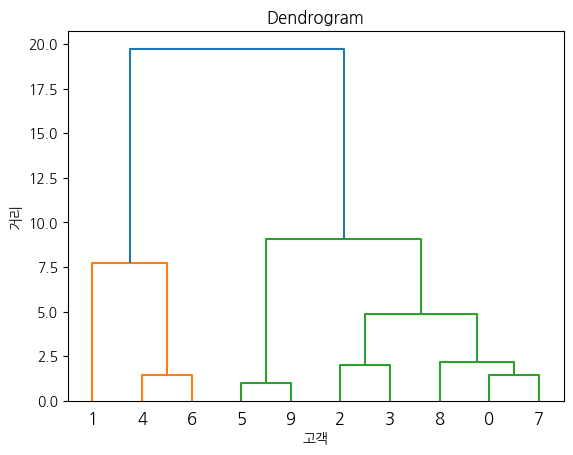

In [116]:
sch.dendrogram( sch.linkage(X, method='ward' ) )
plt.title('Dendrogram')
plt.xlabel('고객')
plt.ylabel('거리')
plt.show()

In [94]:
from sklearn.cluster import AgglomerativeClustering

In [106]:
hc = AgglomerativeClustering(n_clusters = 3)

In [107]:
y_pred = hc.fit_predict(X)

In [108]:
df['Group'] = y_pred

In [109]:
df.loc[df['Group'] == 0,]

,Cust_ID,Name,Avg_Mthly_Spend,No_Of_Visits,Apparel_Items,FnV_Items,Staples_Items,Group
1,2,B,7000,3,0,10,9,0
4,5,E,6000,6,0,12,3,0
6,7,G,2500,5,0,11,2,0


In [110]:
df.loc[df['Group'] == 1,]

,Cust_ID,Name,Avg_Mthly_Spend,No_Of_Visits,Apparel_Items,FnV_Items,Staples_Items,Group
0,1,A,10000,2,1,1,0,1
2,3,C,7000,7,1,3,4,1
3,4,D,6500,5,1,1,4,1
7,8,H,2500,3,0,1,1,1
8,9,I,2000,2,0,2,2,1


In [111]:
df.loc[df['Group'] == 2,]

,Cust_ID,Name,Avg_Mthly_Spend,No_Of_Visits,Apparel_Items,FnV_Items,Staples_Items,Group
5,6,F,4000,3,0,1,8,2
9,10,J,1000,4,0,1,7,2
